In [2]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
import pandas as pd
import numpy as np
import json
import os
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score, accuracy_score,
    mean_absolute_error, mean_squared_error
)
from google.colab import drive

drive.mount('/content/drive')

BASE          = '/content/drive/MyDrive/CDT_Dataset'
HUMAN_FOLDER  = f'{BASE}/images_human_fixed'
RESULT_FOLDER = f'{BASE}/results'
MODEL_FOLDER = f'{BASE}/models_human_undersample'

os.makedirs(RESULT_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER,  exist_ok=True)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
CUTOFF = 6
print(f'Device: {device}')

Mounted at /content/drive
Device: cuda


In [4]:
train_df = pd.read_csv(
    f'{BASE}/labels/human_train.csv'
)
val_df   = pd.read_csv(
    f'{BASE}/labels/human_val.csv'
)
test_df  = pd.read_csv(
    f'{BASE}/labels/human_test.csv'
)

for d in [train_df, val_df, test_df]:
    d['dementia_risk'] = d['dementia_risk'].astype(bool)

print('ก่อน undersample:')
print(f'  Normal  : {(~train_df["dementia_risk"]).sum()}')
print(f'  Dementia: {train_df["dementia_risk"].sum()}')
print(f'  Total   : {len(train_df)}')

TARGET_NORMAL   = 2000
TARGET_DEMENTIA = 1200

dementia_df = train_df[train_df['dementia_risk']]
normal_df   = train_df[~train_df['dementia_risk']]

normal_sampled = normal_df.sample(
    n=min(TARGET_NORMAL, len(normal_df)),
    random_state=42
)

print(f'\nหลัง undersample Normal:')
print(f'  Normal  : {len(normal_sampled)}')
print(f'  Dementia: {len(dementia_df)}')

AUG_FOLDER = f'{BASE}/images_human_aug'
os.makedirs(AUG_FOLDER, exist_ok=True)

need_more = max(0, TARGET_DEMENTIA - len(dementia_df))
print(f'\nAugment plan:')
print(f'  Dementia ตอนนี้: {len(dementia_df)}')
print(f'  Target         : {TARGET_DEMENTIA}')
print(f'  ต้องเพิ่ม      : {need_more} รูป')

def augment_image_no_rotation(img):
    factor = random.uniform(0.8, 1.2)
    img    = ImageEnhance.Brightness(img).enhance(factor)
    factor = random.uniform(0.8, 1.2)
    img    = ImageEnhance.Contrast(img).enhance(factor)
    zoom   = random.uniform(0.9, 1.1)
    w, h   = img.size
    new_w  = int(w * zoom)
    new_h  = int(h * zoom)
    img    = img.resize((new_w, new_h), Image.LANCZOS)
    left   = max(0, (new_w - w) // 2)
    top    = max(0, (new_h - h) // 2)
    img    = img.crop((left, top,
                       left + min(w, new_w),
                       top  + min(h, new_h)))
    img    = img.resize((w, h), Image.LANCZOS)
    return img

aug_rows  = []
generated = 0

if need_more > 0:
    print('\nกำลัง augment dementia...')
    while generated < need_more:
        for _, row in dementia_df.iterrows():
            if generated >= need_more:
                break
            try:
                src = f'{HUMAN_FOLDER}/{row["filename"]}'
                img = Image.open(src).convert('RGB')
                aug = augment_image_no_rotation(img)

                new_name = (
                    f'aug_k_{generated:05d}_'
                    f'{row["filename"]}'
                )
                aug.save(
                    f'{AUG_FOLDER}/{new_name}',
                    'JPEG', quality=95
                )

                new_row             = row.copy()
                new_row['filename'] = new_name
                aug_rows.append(new_row)
                generated += 1
            except:
                continue

    aug_df      = pd.DataFrame(aug_rows)
    dementia_df = pd.concat(
        [dementia_df, aug_df], ignore_index=True
    )
    print(f'  Augment เสร็จ: {generated} รูป')

train_df = pd.concat(
    [normal_sampled, dementia_df],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(
    drop=True
)

print(f'\nTrain set สุดท้าย:')
print(f'  Normal  : {(~train_df["dementia_risk"]).sum()}')
print(f'  Dementia: {train_df["dementia_risk"].sum()}')
print(f'  Total   : {len(train_df)}')
print(f'  Ratio   : '
      f'{(~train_df["dementia_risk"]).sum() / train_df["dementia_risk"].sum():.1f}:1')
print(f'\nVal : {len(val_df)} รูป')
print(f'Test: {len(test_df)} รูป')

ก่อน undersample:
  Normal  : 3839
  Dementia: 782
  Total   : 4621

หลัง undersample Normal:
  Normal  : 2000
  Dementia: 782

Augment plan:
  Dementia ตอนนี้: 782
  Target         : 1200
  ต้องเพิ่ม      : 418 รูป

กำลัง augment dementia...
  Augment เสร็จ: 418 รูป

Train set สุดท้าย:
  Normal  : 2000
  Dementia: 1200
  Total   : 3200
  Ratio   : 1.7:1

Val : 653 รูป
Test: 1328 รูป


In [5]:
class CDTDataset(Dataset):
    def __init__(self, df, human_folder,
                 aug_folder=None, transform=None):
        self.df           = df.reset_index(drop=True)
        self.human_folder = human_folder
        self.aug_folder   = aug_folder
        self.transform    = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        filename = row['filename']

        if (self.aug_folder and
                filename.startswith('aug_')):
            img_path = f'{self.aug_folder}/{filename}'
        else:
            img_path = f'{self.human_folder}/{filename}'

        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224),
                           (255, 255, 255))

        if self.transform:
            img = self.transform(img)

        labels = torch.tensor([
            row['domain_A'], row['domain_B'],
            row['domain_C'], row['domain_D'],
            row['domain_E']
        ], dtype=torch.float32)

        return img, labels

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [6]:
class CDTModel(nn.Module):
    def __init__(self, backbone_name='resnet50',
                 num_domains=5, num_classes=3):
        super().__init__()

        if backbone_name == 'resnet50':
            backbone = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            self.feature_dim = 2048
            for param in backbone.parameters():
                param.requires_grad = False
            self.backbone = nn.Sequential(
                *list(backbone.children())[:-1]
            )

        elif backbone_name == 'vit':
            self.backbone = timm.create_model(
                'vit_base_patch16_224',
                pretrained=True,
                num_classes=0
            )
            self.feature_dim = 768
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.backbone_name = backbone_name
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.heads_cls = nn.ModuleList([
            nn.Linear(512, num_classes)
            for _ in range(num_domains)
        ])
        self.heads_reg = nn.ModuleList([
            nn.Linear(512, 1)
            for _ in range(num_domains)
        ])

    def forward(self, x, mode='reg'):
        if self.backbone_name == 'resnet50':
            feat = self.backbone(x)
        else:
            feat = self.backbone(x)
            feat = feat.unsqueeze(-1).unsqueeze(-1)
        feat = self.shared(feat)
        if mode == 'reg':
            return [head(feat).squeeze(-1)
                    for head in self.heads_reg]
        else:
            return [head(feat)
                    for head in self.heads_cls]

In [7]:
DOMAIN_WEIGHTS = torch.tensor(
    [1.0, 1.5, 1.0, 1.0, 1.0]
).to(device)

def compute_loss(outputs, labels, mode='reg'):
    total_loss = 0
    for i, output in enumerate(outputs):
        if mode == 'reg':
            loss = nn.MSELoss()(
                output, labels[:, i].float()
            )
        else:
            loss = nn.CrossEntropyLoss()(
                output, labels[:, i].long()
            )
        total_loss += loss * DOMAIN_WEIGHTS[i]
    return total_loss / DOMAIN_WEIGHTS.sum()

def get_predictions(outputs, mode='reg'):
    preds = []
    for output in outputs:
        if mode == 'reg':
            pred = output.round().clamp(0, 2).long()
        else:
            pred = output.argmax(dim=1)
        preds.append(pred)
    return torch.stack(preds, dim=1)

def evaluate_model(model, loader, mode='reg'):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images, mode=mode)
            preds   = get_predictions(outputs, mode)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    pred_total    = all_preds.sum(axis=1)
    true_total    = all_labels.sum(axis=1)
    pred_dementia = (pred_total < CUTOFF).astype(int)
    true_dementia = (true_total < CUTOFF).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_dementia, pred_dementia, labels=[0,1]
    ).ravel()

    sens = tp/(tp+fn) if (tp+fn) > 0 else 0
    spec = tn/(tn+fp) if (tn+fp) > 0 else 0
    try:
        auc = roc_auc_score(true_dementia, -pred_total)
    except:
        auc = 0

    domain_metrics = {}
    for i, d in enumerate(['A','B','C','D','E']):
        domain_metrics[d] = {
            'acc': accuracy_score(
                all_labels[:,i], all_preds[:,i]),
            'mae': mean_absolute_error(
                all_labels[:,i], all_preds[:,i]),
            'mse': mean_squared_error(
                all_labels[:,i], all_preds[:,i]),
            'f1' : f1_score(
                all_labels[:,i], all_preds[:,i],
                average='macro', zero_division=0),
        }

    return {
        'sensitivity'   : sens,
        'specificity'   : spec,
        'auc'           : auc,
        'f1'            : f1_score(
            true_dementia, pred_dementia,
            zero_division=0),
        'domain_metrics': domain_metrics,
        'avg_acc'       : np.mean([
            m['acc']
            for m in domain_metrics.values()]),
        'avg_mae'       : np.mean([
            m['mae']
            for m in domain_metrics.values()]),
        'pred_total'    : pred_total,
        'true_total'    : true_total,
        'true_dementia' : true_dementia,
    }

In [8]:
def train_model(backbone, mode,
                model_name,
                epochs=20, patience=10):

    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'Backbone: {backbone} | Loss: {mode}')
    print(f'Human Labels + No Rotation Augment')
    print(f'{"="*60}')

    train_ds = CDTDataset(
        train_df, HUMAN_FOLDER,
        AUG_FOLDER if need_more > 0 else None,
        train_transform
    )
    val_ds = CDTDataset(
        val_df, HUMAN_FOLDER, None, val_transform
    )
    test_ds = CDTDataset(
        test_df, HUMAN_FOLDER, None, val_transform
    )

    train_loader = DataLoader(
        train_ds, batch_size=16,
        shuffle=True, num_workers=2
    )
    val_loader = DataLoader(
        val_ds, batch_size=16,
        shuffle=False, num_workers=2
    )
    test_loader = DataLoader(
        test_ds, batch_size=16,
        shuffle=False, num_workers=2
    )

    model = CDTModel(backbone_name=backbone).to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad,
               model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.5
    )

    best_combined = -1
    best_state    = None
    no_improve    = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'sensitivity': [], 'specificity': [],
        'auc': []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images, mode=mode)
            loss    = compute_loss(outputs, labels, mode)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        val_results = evaluate_model(
            model, val_loader, mode=mode
        )

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images, mode=mode)
                loss    = compute_loss(
                    outputs, labels, mode
                )
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['sensitivity'].append(
            val_results['sensitivity'])
        history['specificity'].append(
            val_results['specificity'])
        history['auc'].append(val_results['auc'])

        combined = (val_results['sensitivity'] +
                    val_results['specificity']) / 2
        if combined > best_combined:
            best_combined = combined
            best_state    = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping epoch {epoch+1}')
                break

        print(f'Epoch {epoch+1:2d}/{epochs} | '
              f'Loss: {train_loss:.4f}/{val_loss:.4f} | '
              f'Sens: {val_results["sensitivity"]:.3f} | '
              f'Spec: {val_results["specificity"]:.3f} | '
              f'AUC: {val_results["auc"]:.3f}')

    model.load_state_dict(best_state)
    torch.save(
        best_state,
        f'{MODEL_FOLDER}/{model_name}_best.pth'
    )
    with open(
        f'{RESULT_FOLDER}/history_{model_name}.json',
        'w'
    ) as f:
        json.dump(history, f)

    test_results = evaluate_model(
        model, test_loader, mode=mode
    )

    return model, history, test_results

In [10]:
results_human = {}

for backbone, mode in [
    ('resnet50', 'reg'),
    ('resnet50', 'cls'),
    ('vit',      'reg'),
    ('vit',      'cls'),
]:
    epochs     = 15 if backbone == 'vit' else 20
    model_name = f'human_us_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    if os.path.exists(path):
        print(f'\nโหลด {model_name}')
        model = CDTModel(backbone_name=backbone).to(device)
        model.load_state_dict(
            torch.load(path, map_location=device)
        )
        model.eval()

        test_ds = CDTDataset(
            test_df, HUMAN_FOLDER,
            None, val_transform
        )
        test_loader = DataLoader(
            test_ds, batch_size=16, shuffle=False
        )
        test_results = evaluate_model(
            model, test_loader, mode=mode
        )
    else:
        _, _, test_results = train_model(
            backbone, mode,
            model_name,
            epochs=epochs, patience=10
        )

    results_human[f'{backbone}_{mode}'] = test_results

    print(f'\n{model_name}:')
    print(f'  Sensitivity : '
          f'{test_results["sensitivity"]:.3f} '
          f'{"✅" if test_results["sensitivity"]>=0.88 else "⚠️"}')
    print(f'  Specificity : '
          f'{test_results["specificity"]:.3f} '
          f'{"✅" if test_results["specificity"]>=0.82 else "⚠️"}')
    print(f'  AUC         : '
          f'{test_results["auc"]:.3f} '
          f'{"✅" if test_results["auc"]>=0.91 else "⚠️"}')
    print(f'  Avg Domain  : '
          f'{test_results["avg_acc"]:.3f}')


โหลด human_us_resnet50_reg

human_us_resnet50_reg:
  Sensitivity : 0.649 ⚠️
  Specificity : 0.872 ✅
  AUC         : 0.856 ⚠️
  Avg Domain  : 0.624

โหลด human_us_resnet50_cls

human_us_resnet50_cls:
  Sensitivity : 0.809 ⚠️
  Specificity : 0.772 ⚠️
  AUC         : 0.869 ⚠️
  Avg Domain  : 0.684

โหลด human_us_vit_reg


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


human_us_vit_reg:
  Sensitivity : 0.751 ⚠️
  Specificity : 0.844 ✅
  AUC         : 0.882 ⚠️
  Avg Domain  : 0.616

โหลด human_us_vit_cls



human_us_vit_cls:
  Sensitivity : 0.671 ⚠️
  Specificity : 0.898 ✅
  AUC         : 0.863 ⚠️
  Avg Domain  : 0.739


In [9]:
print('='*60)
print('Cutoff Analysis — Human Labels')
print('='*60)

for key, results in results_human.items():
    pred_total    = results['pred_total']
    true_dementia = results['true_dementia']

    print(f'\n{key}:')
    print(f'{"Cutoff":>8} {"Sens":>8} '
          f'{"Spec":>8} {"AUC":>8}')
    print('-'*38)

    for cutoff in [5, 6, 7, 8]:
        pred = (pred_total < cutoff).astype(int)
        try:
            tn, fp, fn, tp = confusion_matrix(
                true_dementia, pred, labels=[0,1]
            ).ravel()
            sens = tp/(tp+fn) if (tp+fn) > 0 else 0
            spec = tn/(tn+fp) if (tn+fp) > 0 else 0
            auc  = roc_auc_score(
                true_dementia, -pred_total
            )
        except:
            sens, spec, auc = 0, 0, 0

        mark = '✅' if (sens >= 0.88 and
                       spec >= 0.82) else '⚠️'
        print(f'{cutoff:>8} {sens:>8.3f} '
              f'{spec:>8.3f} {auc:>8.3f} {mark}')

Cutoff Analysis — Human Labels

resnet50_reg:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.276    0.991    0.857 ⚠️
       6    0.649    0.873    0.857 ⚠️
       7    0.742    0.815    0.857 ⚠️
       8    0.929    0.549    0.857 ⚠️

resnet50_cls:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.724    0.859    0.870 ⚠️
       6    0.809    0.772    0.870 ⚠️
       7    0.893    0.684    0.870 ⚠️
       8    0.902    0.657    0.870 ⚠️

vit_reg:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.489    0.976    0.882 ⚠️
       6    0.751    0.844    0.882 ⚠️
       7    0.813    0.770    0.882 ⚠️
       8    0.951    0.511    0.882 ⚠️

vit_cls:
  Cutoff     Sens     Spec      AUC
--------------------------------------
       5    0.507    0.951    0.863 ⚠️
       6    0.671    0.898    0.863 ⚠️
       7    0.751    0.870    0.863 ⚠️
       8    0.778    0.844    0.86

In [14]:
llm_human_path = (
    f'{RESULT_FOLDER}/baseline_llm_human.json'
)
with open(llm_human_path) as f:
    llm_human = json.load(f)

llm_h_auc  = llm_human['auc_roc']

cutoff6    = llm_human['cutoff_results']['6']
llm_h_sens = cutoff6['sensitivity']
llm_h_spec = cutoff6['specificity']

print(f'LLM Baseline (cutoff=6):')
print(f'  Sens={llm_h_sens:.3f} '
      f'Spec={llm_h_spec:.3f} '
      f'AUC={llm_h_auc:.3f}')

LLM Baseline (cutoff=6):
  Sens=0.600 Spec=0.967 AUC=0.873


In [17]:
with open(
    f'{RESULT_FOLDER}/07j_human_results.json'
) as f:
    results_07j = json.load(f)

human_07j = results_07j.get('human_models', {})

llm_human_path = (
    f'{RESULT_FOLDER}/baseline_llm_human.json'
)
if os.path.exists(llm_human_path):
    with open(llm_human_path) as f:
        llm_human = json.load(f)
    llm_h_auc  = llm_human['auc_roc']
    llm_h_sens = llm_human['cutoff_results']['6']['sensitivity']
    llm_h_spec = llm_human['cutoff_results']['6']['specificity']
else:
    print('⚠️ ไม่พบ baseline_llm_human.json')
    llm_h_auc  = 0.873
    llm_h_sens = 0.711
    llm_h_spec = 0.925

print('='*95)
print('COMPARISON: LLM Baseline vs 07j vs 07k')
print('='*95)
print(f'{"Model":<20} {"LLM Baseline":>13} '
      f'{"07j":>12} {"07k":>12} {"Best":>12}')
print(f'{"":20} {"AUC":>13} '
      f'{"AUC":>12} {"AUC":>12}')
print('='*95)

for key in results_human:
    j_auc = human_07j.get(key, {}).get('auc', 0)
    k_auc = results_human[key]['auc']

    best_auc = max(llm_h_auc, j_auc, k_auc)
    best = {
        llm_h_auc: 'LLM Baseline',
        j_auc    : '07j',
        k_auc    : '07k',
    }[best_auc]

    j_m = '✅' if j_auc > llm_h_auc else '⚠️'
    k_m = '✅' if k_auc > llm_h_auc else '⚠️'

    print(f'{key:<20} {llm_h_auc:>13.3f} '
          f'{j_auc:>11.3f}{j_m} '
          f'{k_auc:>11.3f}{k_m} '
          f'{best:>12}')

print('='*95)

# Sens/Spec
print(f'\nSensitivity/Specificity (cutoff=6):')
print(f'{"Model":<20} {"LLM Baseline":>15} '
      f'{"07j":>15} {"07k":>15}')
print('-'*68)

llm_str = f'{llm_h_sens:.3f}/{llm_h_spec:.3f}'

for key in results_human:
    j = human_07j.get(key, {})
    k = results_human[key]

    j_str = (f'{j["sensitivity"]:.3f}/'
             f'{j["specificity"]:.3f}'
             if j else 'N/A')
    k_str = (f'{k["sensitivity"]:.3f}/'
             f'{k["specificity"]:.3f}')

    k_pass = '✅' if (
        k['sensitivity'] >= 0.88 and
        k['specificity'] >= 0.82
    ) else ''

    print(f'{key:<20} {llm_str:>15} '
          f'{j_str:>15} '
          f'{k_str:>14}{k_pass}')

print('-'*68)
print(f'{"Target":<20} {"≥0.880/≥0.820":>15}')
print(f'\n⚠️ LLM Baseline วัดกับ human test set')
print(f'   AUC={llm_h_auc:.3f} '
      f'Sens={llm_h_sens:.3f} '
      f'Spec={llm_h_spec:.3f}')

with open(
    f'{RESULT_FOLDER}/07k_undersample_results.json',
    'w'
) as f:
    json.dump({
        'train_normal'  : TARGET_NORMAL,
        'train_dementia': TARGET_DEMENTIA,
        'ratio'         : f'{TARGET_NORMAL/TARGET_DEMENTIA:.1f}:1',
        'llm_baseline'  : {
            'auc' : llm_h_auc,
            'sens': llm_h_sens,
            'spec': llm_h_spec,
        },
        'results_07j'   : {
            k: {
                'auc' : float(
                    human_07j.get(k, {}).get('auc', 0)),
                'sensitivity': float(
                    human_07j.get(k, {}).get(
                        'sensitivity', 0)),
                'specificity': float(
                    human_07j.get(k, {}).get(
                        'specificity', 0)),
            }
            for k in results_human
        },
        'results_07k'   : {
            k: {
                'sensitivity': float(v['sensitivity']),
                'specificity': float(v['specificity']),
                'auc'        : float(v['auc']),
            }
            for k, v in results_human.items()
        }
    }, f, indent=2)

COMPARISON: LLM Baseline vs 07j vs 07k
Model                 LLM Baseline          07j          07k         Best
                               AUC          AUC          AUC
resnet50_reg                 0.873       0.845⚠️       0.857⚠️ LLM Baseline
resnet50_cls                 0.873       0.859⚠️       0.870⚠️ LLM Baseline
vit_reg                      0.873       0.872⚠️       0.882✅          07k
vit_cls                      0.873       0.853⚠️       0.863⚠️ LLM Baseline

Sensitivity/Specificity (cutoff=6):
Model                   LLM Baseline             07j             07k
--------------------------------------------------------------------
resnet50_reg             0.600/0.967     0.827/0.718    0.649/0.873
resnet50_cls             0.600/0.967     0.578/0.936    0.809/0.772
vit_reg                  0.600/0.967     0.582/0.922    0.751/0.844
vit_cls                  0.600/0.967     0.582/0.958    0.671/0.898
--------------------------------------------------------------------
Target 

In [22]:
best_backbone = 'resnet50'
best_mode     = 'reg'
model_name    = f'human_us_{best_backbone}_{best_mode}'
path          = f'{MODEL_FOLDER}/{model_name}_best.pth'

model = CDTModel(backbone_name=best_backbone).to(device)
model.load_state_dict(
    torch.load(path, map_location=device)
)
model.eval()

test_ds = CDTDataset(
    test_df, HUMAN_FOLDER, None, val_transform
)
test_loader = DataLoader(
    test_ds, batch_size=16, shuffle=False
)

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images, mode=best_mode)
        preds   = get_predictions(outputs, best_mode)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(f'all_preds shape : {all_preds.shape}')
print(f'all_labels shape: {all_labels.shape}')
print(f'model: {model_name}')

all_preds shape : (1328, 5)
all_labels shape: (1328, 5)
model: human_us_resnet50_reg


/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_947/2380013802.py:97: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt

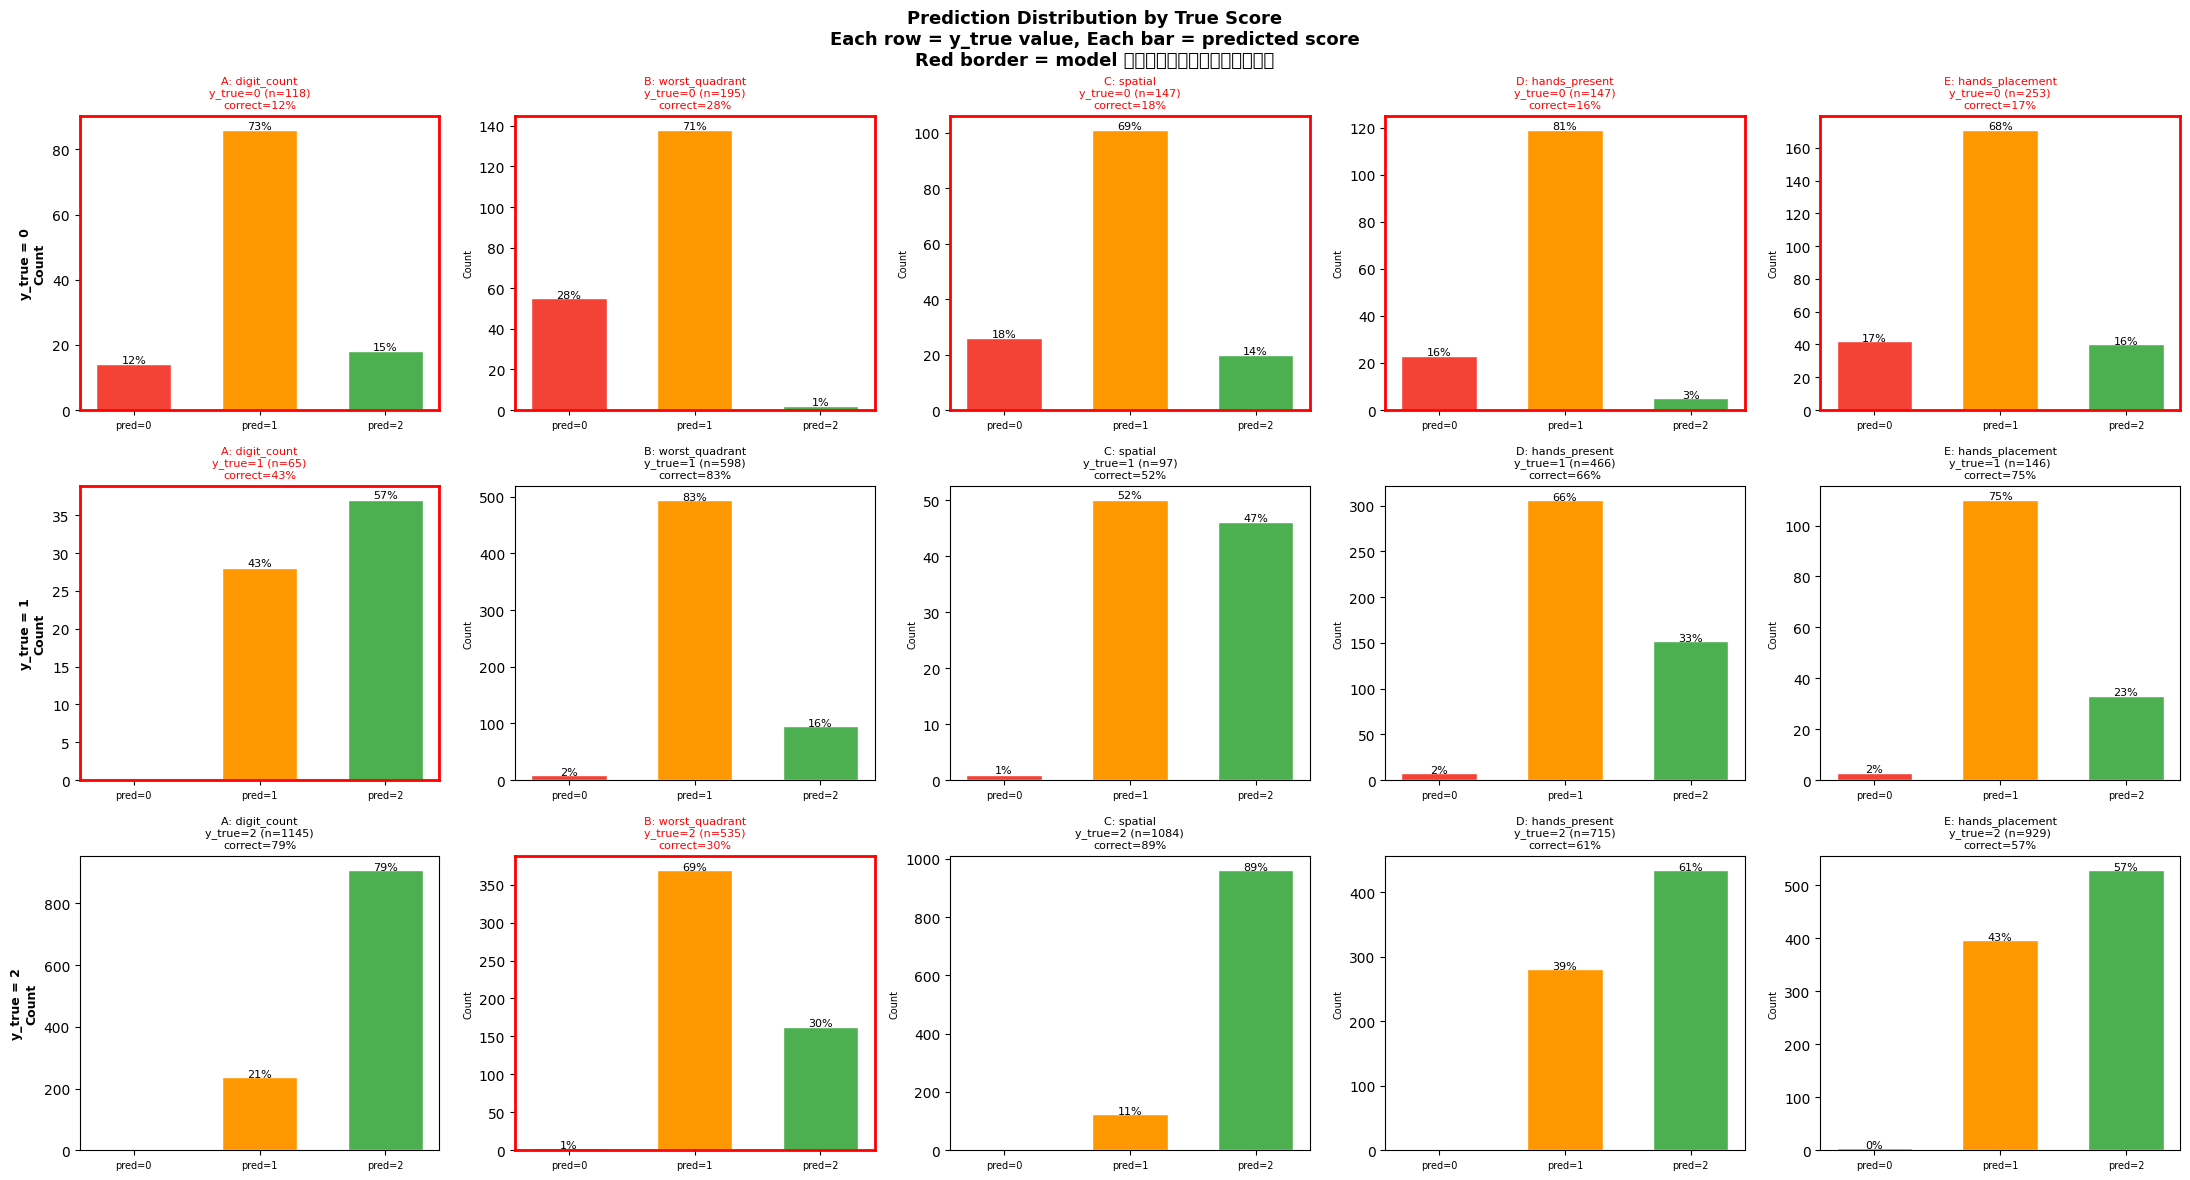

Prediction Distribution Summary

A: digit_count:
    y_true   pred=0   pred=1   pred=2   correct%
  ------------------------------------------------
         0       14       86       18      11.9% ⚠️
         1        0       28       37      43.1% ⚠️
         2        0      238      907      79.2% ✅

B: worst_quadrant:
    y_true   pred=0   pred=1   pred=2   correct%
  ------------------------------------------------
         0       55      138        2      28.2% ⚠️
         1        9      494       95      82.6% ✅
         2        3      369      163      30.5% ⚠️

C: spatial:
    y_true   pred=0   pred=1   pred=2   correct%
  ------------------------------------------------
         0       26      101       20      17.7% ⚠️
         1        1       50       46      51.5% ⚠️
         2        0      123      961      88.7% ✅

D: hands_present:
    y_true   pred=0   pred=1   pred=2   correct%
  ------------------------------------------------
         0       23      119      

In [23]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12))

domain_names = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}

colors = {0: '#F44336', 1: '#FF9800', 2: '#4CAF50'}
labels_name = {0: 'Score 0', 1: 'Score 1', 2: 'Score 2'}

for d_idx, d_name in domain_names.items():
    true_d = all_labels[:, d_idx].astype(int)
    pred_d = all_preds[:, d_idx].astype(int)

    for true_val in [0, 1, 2]:
        ax = axes[true_val][d_idx]

        # กรองเฉพาะ y_true == true_val
        mask       = (true_d == true_val)
        pred_given = pred_d[mask]
        n_total    = mask.sum()

        if n_total == 0:
            ax.text(0.5, 0.5, 'No data',
                    ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_title(f'{d_name}\ny_true={true_val}',
                         fontsize=8)
            continue

        # นับ pred แต่ละค่า
        counts = {
            v: (pred_given == v).sum()
            for v in [0, 1, 2]
        }
        pcts = {
            v: c/n_total*100
            for v, c in counts.items()
        }

        bars = ax.bar(
            [0, 1, 2],
            [counts[v] for v in [0, 1, 2]],
            color=[colors[v] for v in [0, 1, 2]],
            edgecolor='white', width=0.6
        )

        # ใส่ % บน bar
        for bar, v in zip(bars, [0, 1, 2]):
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.3,
                    f'{pcts[v]:.0f}%',
                    ha='center', fontsize=8
                )

        # กรอบสีแดงถ้าทายผิดส่วนใหญ่
        correct_pct = pcts[true_val]
        if correct_pct < 50:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(2)

        ax.set_title(
            f'{d_name}\n'
            f'y_true={true_val} (n={n_total})\n'
            f'correct={correct_pct:.0f}%',
            fontsize=8,
            color='red' if correct_pct < 50 else 'black'
        )
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(
            ['pred=0', 'pred=1', 'pred=2'],
            fontsize=7
        )
        ax.set_ylabel('Count', fontsize=7)

# Row labels
for true_val in [0, 1, 2]:
    axes[true_val][0].set_ylabel(
        f'y_true = {true_val}\nCount',
        fontsize=9, fontweight='bold'
    )

plt.suptitle(
    'Prediction Distribution by True Score\n'
    'Each row = y_true value, '
    'Each bar = predicted score\n'
    'Red border = model ทายผิดส่วนใหญ่',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07k_pred_distribution.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Print สรุป ──
print('='*65)
print('Prediction Distribution Summary')
print('='*65)

for d_idx, d_name in domain_names.items():
    true_d = all_labels[:, d_idx].astype(int)
    pred_d = all_preds[:, d_idx].astype(int)

    print(f'\n{d_name}:')
    print(f'  {"y_true":>8} {"pred=0":>8} '
          f'{"pred=1":>8} {"pred=2":>8} '
          f'{"correct%":>10}')
    print('  ' + '-'*48)

    for true_val in [0, 1, 2]:
        mask    = (true_d == true_val)
        n       = mask.sum()
        if n == 0:
            continue
        pred_g  = pred_d[mask]
        c0      = (pred_g == 0).sum()
        c1      = (pred_g == 1).sum()
        c2      = (pred_g == 2).sum()
        correct = (pred_g == true_val).sum()
        pct     = correct/n*100

        mark = '✅' if pct >= 70 else '⚠️'
        print(f'  {true_val:>8} {c0:>8} '
              f'{c1:>8} {c2:>8} '
              f'{pct:>9.1f}% {mark}')

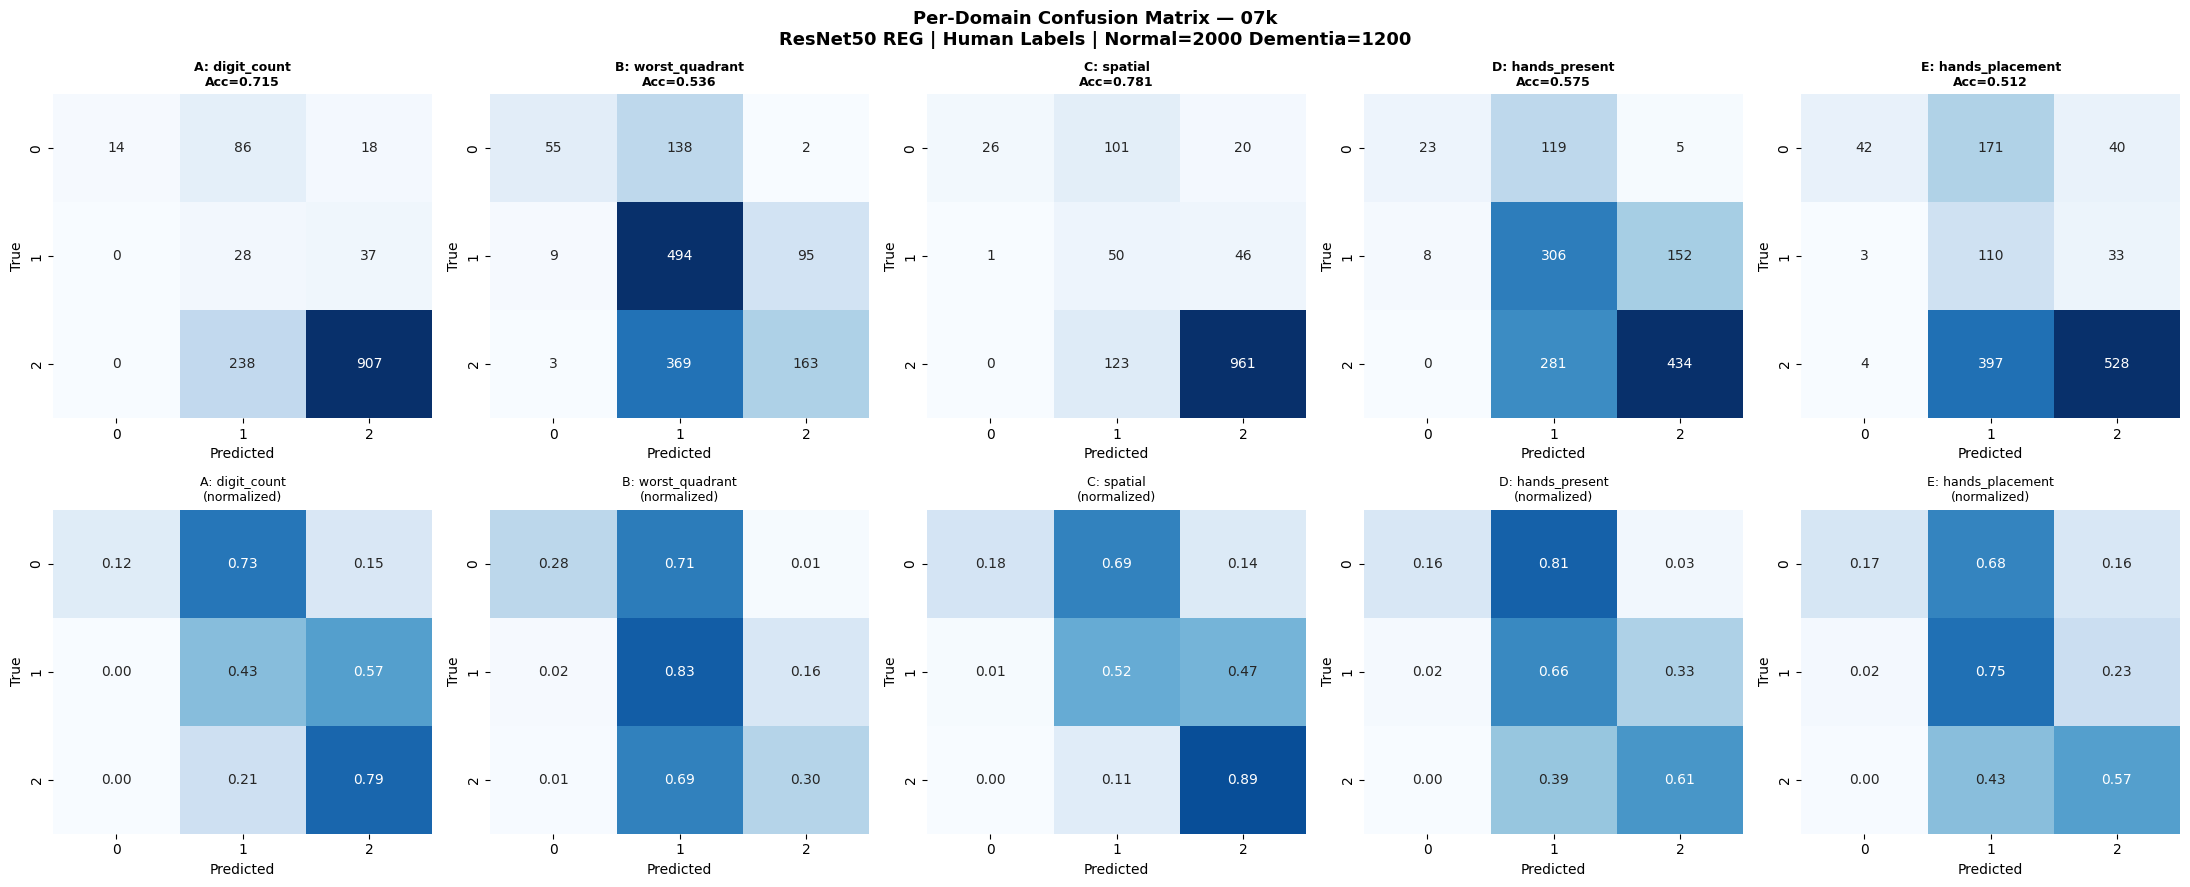

Per-Domain Accuracy — 07k (Undersample)
Domain                         Acc      MAE   Class0%   Class1%   Class2%
-----------------------------------------------------------------
A: digit_count               0.715    0.299     11.9%     43.1%     79.2% 🟢
B: worst_quadrant            0.536    0.468     28.2%     82.6%     30.5% 🔴
C: spatial                   0.781    0.234     17.7%     51.5%     88.7% 🟢
D: hands_present             0.575    0.429     15.6%     65.7%     60.7% 🟡
E: hands_placement           0.512    0.521     16.6%     75.3%     56.8% 🔴
Class0% = acc เมื่อ y_true=0
Class1% = acc เมื่อ y_true=1
Class2% = acc เมื่อ y_true=2


In [24]:
# Confusion Matrix ทุก Domain — 07k
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

domain_names = {
    0: 'A: digit_count',
    1: 'B: worst_quadrant',
    2: 'C: spatial',
    3: 'D: hands_present',
    4: 'E: hands_placement',
}

for d_idx, d_name in domain_names.items():
    true_d = all_labels[:, d_idx].astype(int)
    pred_d = all_preds[:, d_idx].astype(int)

    cm = confusion_matrix(true_d, pred_d, labels=[0,1,2])

    # Normalized
    cm_norm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    cm_norm = cm_norm / row_sum

    # Raw count
    ax_raw  = axes[0][d_idx]
    ax_norm = axes[1][d_idx]

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=ax_raw,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False
    )
    acc = (true_d == pred_d).mean()
    ax_raw.set_title(
        f'{d_name}\nAcc={acc:.3f}',
        fontsize=9, fontweight='bold'
    )
    ax_raw.set_xlabel('Predicted')
    ax_raw.set_ylabel('True')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Blues', ax=ax_norm,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False,
        vmin=0, vmax=1
    )
    ax_norm.set_title(
        f'{d_name}\n(normalized)',
        fontsize=9
    )
    ax_norm.set_xlabel('Predicted')
    ax_norm.set_ylabel('True')

plt.suptitle(
    f'Per-Domain Confusion Matrix — 07k\n'
    f'ResNet50 REG | Human Labels | '
    f'Normal=2000 Dementia=1200',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07k_confusion_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Print สรุป ──
print('='*65)
print('Per-Domain Accuracy — 07k (Undersample)')
print('='*65)
print(f'{"Domain":<25} {"Acc":>8} {"MAE":>8} '
      f'{"Class0%":>9} {"Class1%":>9} {"Class2%":>9}')
print('-'*65)

for d_idx, d_name in domain_names.items():
    true_d  = all_labels[:, d_idx].astype(int)
    pred_d  = all_preds[:, d_idx].astype(int)

    acc = (true_d == pred_d).mean()
    mae = np.abs(true_d - pred_d).mean()

    # accuracy แต่ละ class
    class_acc = []
    for v in [0, 1, 2]:
        mask = (true_d == v)
        if mask.sum() == 0:
            class_acc.append(0)
        else:
            class_acc.append(
                (pred_d[mask] == v).mean() * 100
            )

    diff = '🟢' if acc >= 0.70 else \
           '🟡' if acc >= 0.55 else '🔴'

    print(f'{d_name:<25} {acc:>8.3f} {mae:>8.3f} '
          f'{class_acc[0]:>8.1f}% '
          f'{class_acc[1]:>8.1f}% '
          f'{class_acc[2]:>8.1f}% {diff}')

print('='*65)
print('Class0% = acc เมื่อ y_true=0')
print('Class1% = acc เมื่อ y_true=1')
print('Class2% = acc เมื่อ y_true=2')

✅ โหลด human_us_vit_reg แล้ว
✅ vit_preds shape : (1328, 5)


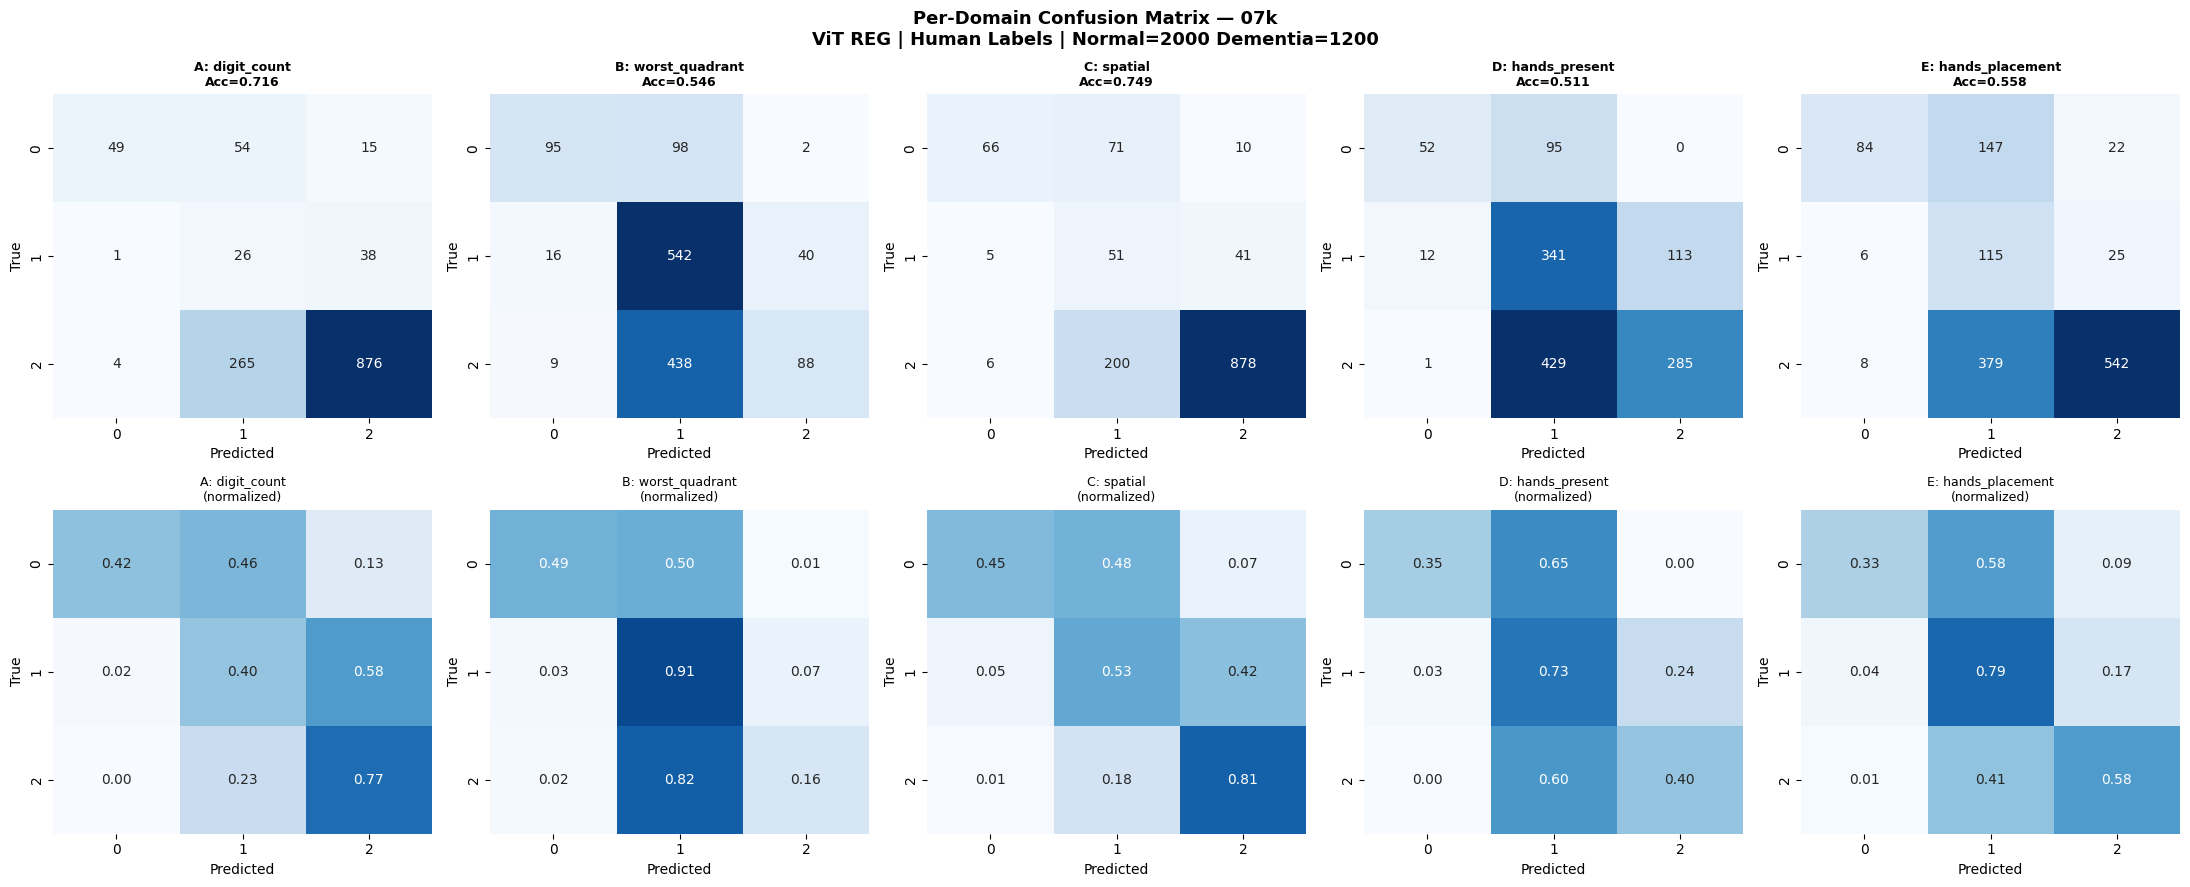

Per-Domain Accuracy — 07k ViT REG
Domain                         Acc      MAE   Class0%   Class1%   Class2%
-----------------------------------------------------------------
A: digit_count               0.716    0.298     41.5%     40.0%     76.5% 🟢
B: worst_quadrant            0.546    0.462     48.7%     90.6%     16.4% 🔴
C: spatial                   0.749    0.263     44.9%     52.6%     81.0% 🟢
D: hands_present             0.511    0.490     35.4%     73.2%     39.9% 🔴
E: hands_placement           0.558    0.465     33.2%     78.8%     58.3% 🟡


In [25]:
# โหลด ViT REG
vit_model_name = f'human_us_vit_reg'
vit_path       = f'{MODEL_FOLDER}/{vit_model_name}_best.pth'

vit_model = CDTModel(backbone_name='vit').to(device)
vit_model.load_state_dict(
    torch.load(vit_path, map_location=device)
)
vit_model.eval()
print(f'✅ โหลด {vit_model_name} แล้ว')

# รัน evaluate
vit_preds  = []
vit_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = vit_model(images, mode='reg')
        preds   = get_predictions(outputs, 'reg')
        vit_preds.append(preds.cpu())
        vit_labels.append(labels.cpu())

vit_preds  = torch.cat(vit_preds).numpy()
vit_labels = torch.cat(vit_labels).numpy()

print(f'✅ vit_preds shape : {vit_preds.shape}')

# ── Confusion Matrix ViT REG ──
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for d_idx, d_name in domain_names.items():
    true_d = vit_labels[:, d_idx].astype(int)
    pred_d = vit_preds[:, d_idx].astype(int)

    cm = confusion_matrix(
        true_d, pred_d, labels=[0,1,2]
    )
    cm_norm = cm.astype(float)
    row_sum = cm.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    cm_norm = cm_norm / row_sum

    ax_raw  = axes[0][d_idx]
    ax_norm = axes[1][d_idx]

    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Blues', ax=ax_raw,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False
    )
    acc = (true_d == pred_d).mean()
    ax_raw.set_title(
        f'{d_name}\nAcc={acc:.3f}',
        fontsize=9, fontweight='bold'
    )
    ax_raw.set_xlabel('Predicted')
    ax_raw.set_ylabel('True')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f',
        cmap='Blues', ax=ax_norm,
        xticklabels=['0','1','2'],
        yticklabels=['0','1','2'],
        cbar=False,
        vmin=0, vmax=1
    )
    ax_norm.set_title(
        f'{d_name}\n(normalized)',
        fontsize=9
    )
    ax_norm.set_xlabel('Predicted')
    ax_norm.set_ylabel('True')

plt.suptitle(
    f'Per-Domain Confusion Matrix — 07k\n'
    f'ViT REG | Human Labels | '
    f'Normal=2000 Dementia=1200',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07k_vit_reg_confusion_matrix.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── Print สรุป ──
print('='*65)
print('Per-Domain Accuracy — 07k ViT REG')
print('='*65)
print(f'{"Domain":<25} {"Acc":>8} {"MAE":>8} '
      f'{"Class0%":>9} {"Class1%":>9} {"Class2%":>9}')
print('-'*65)

for d_idx, d_name in domain_names.items():
    true_d = vit_labels[:, d_idx].astype(int)
    pred_d = vit_preds[:, d_idx].astype(int)

    acc = (true_d == pred_d).mean()
    mae = np.abs(true_d - pred_d).mean()

    class_acc = []
    for v in [0, 1, 2]:
        mask = (true_d == v)
        if mask.sum() == 0:
            class_acc.append(0)
        else:
            class_acc.append(
                (pred_d[mask] == v).mean() * 100
            )

    diff = '🟢' if acc >= 0.70 else \
           '🟡' if acc >= 0.55 else '🔴'

    print(f'{d_name:<25} {acc:>8.3f} {mae:>8.3f} '
          f'{class_acc[0]:>8.1f}% '
          f'{class_acc[1]:>8.1f}% '
          f'{class_acc[2]:>8.1f}% {diff}')

print('='*65)

In [11]:
all_models = {}

for backbone, mode in [
    ('resnet50', 'reg'),
    ('resnet50', 'cls'),
    ('vit',      'reg'),
    ('vit',      'cls'),
]:
    model_name = f'human_us_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    if not os.path.exists(path):
        print(f'ไม่พบ {model_name}')
        continue

    m = CDTModel(backbone_name=backbone).to(device)
    m.load_state_dict(
        torch.load(path, map_location=device)
    )
    m.eval()
    print(f'โหลด {model_name}')

    m_preds  = []
    m_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = m(images, mode=mode)
            preds   = get_predictions(outputs, mode)
            m_preds.append(preds.cpu())
            m_labels.append(labels.cpu())

    m_preds  = torch.cat(m_preds).numpy()
    m_labels = torch.cat(m_labels).numpy()

    all_models[f'{backbone}_{mode}'] = {
        'preds' : m_preds,
        'labels': m_labels,
        'mode'  : mode,
    }

โหลด human_us_resnet50_reg
โหลด human_us_resnet50_cls
โหลด human_us_vit_reg
โหลด human_us_vit_cls


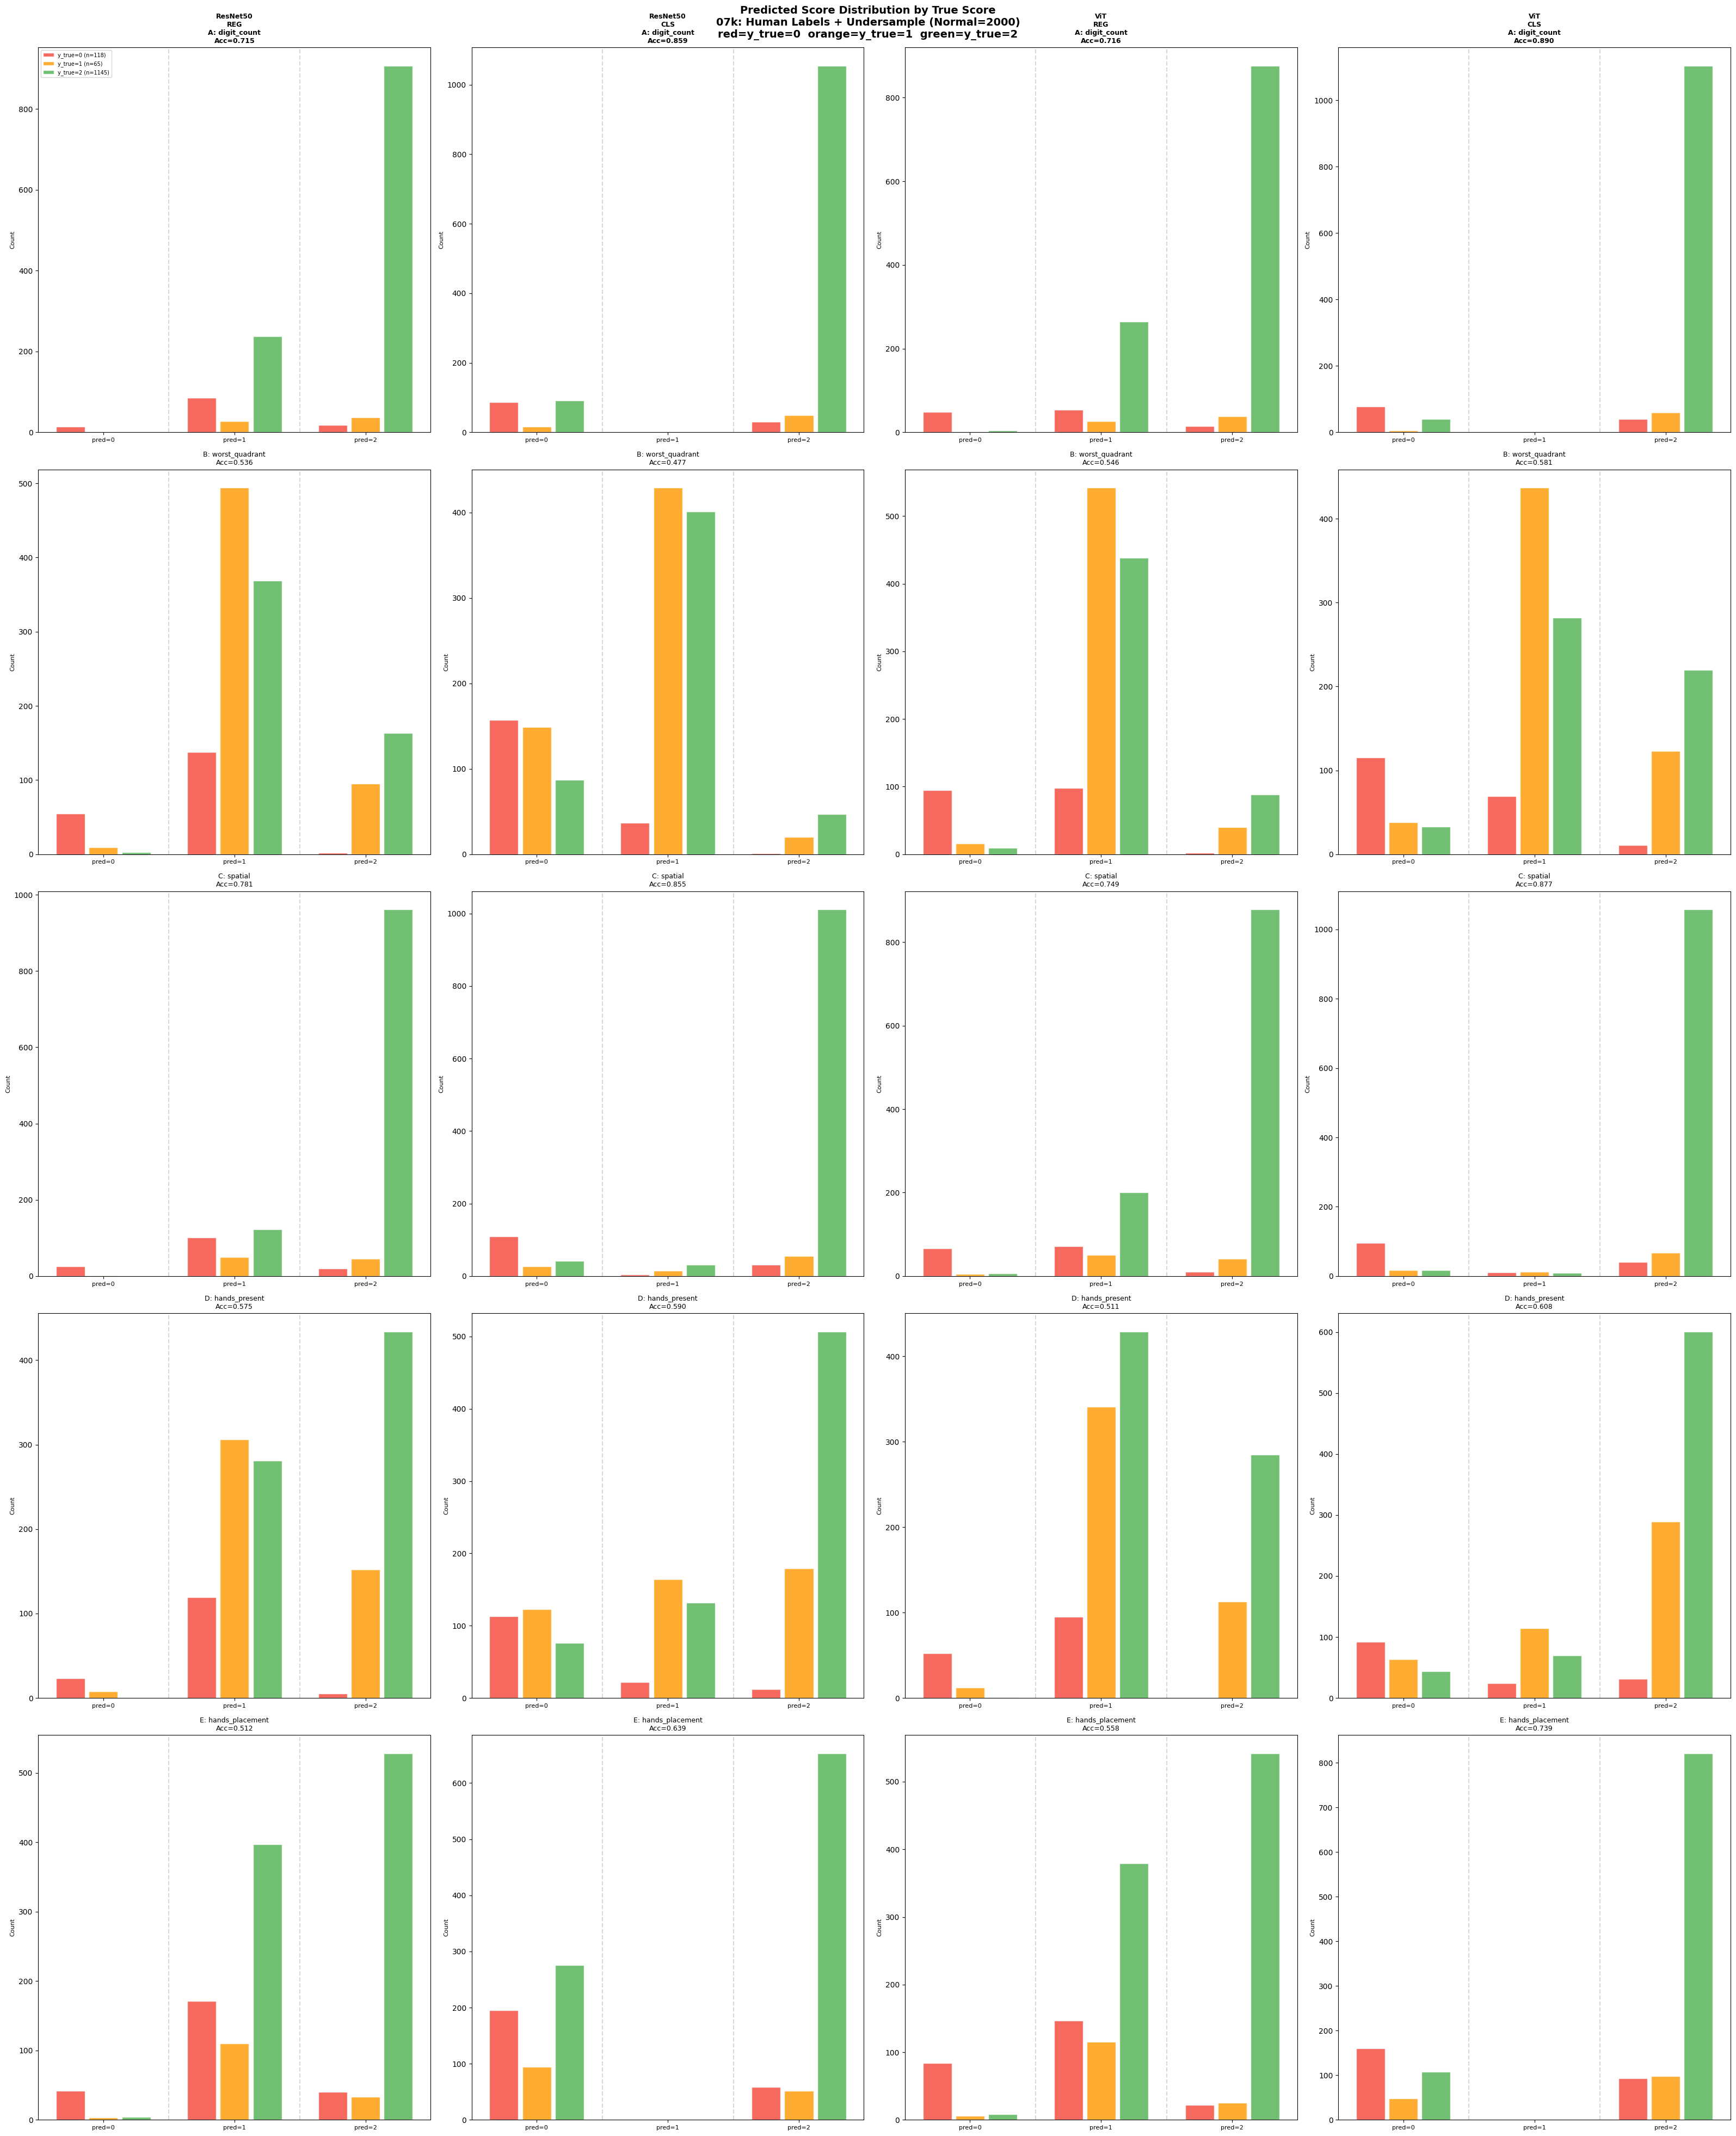

In [31]:
domain_names_list = [
    (0, 'A: digit_count'),
    (1, 'B: worst_quadrant'),
    (2, 'C: spatial'),
    (3, 'D: hands_present'),
    (4, 'E: hands_placement'),
]

colors_true = {
    0: '#F44336',
    1: '#FF9800',
    2: '#4CAF50',
}

model_keys  = list(all_models.keys())
n_models    = len(model_keys)
short_names = {
    'resnet50_reg': 'ResNet50\nREG',
    'resnet50_cls': 'ResNet50\nCLS',
    'vit_reg'     : 'ViT\nREG',
    'vit_cls'     : 'ViT\nCLS',
}
fig, axes = plt.subplots(
    5, n_models,
    figsize=(n_models * 8, 5 * 8)
)

for d_idx, d_name in domain_names_list:
    for m_idx, m_key in enumerate(model_keys):
        ax     = axes[d_idx][m_idx]
        labels = all_models[m_key]['labels']
        preds  = all_models[m_key]['preds']
        true_d = labels[:, d_idx].astype(int)
        pred_d = preds[:, d_idx].astype(int)

        for true_val in [0, 1, 2]:
            mask       = (true_d == true_val)
            pred_given = pred_d[mask]
            n          = mask.sum()
            if n == 0:
                continue

            counts = [
                (pred_given == v).sum()
                for v in [0, 1, 2]
            ]

            ax.bar(
                [v + true_val * 0.25 - 0.25
                 for v in [0, 1, 2]],
                counts,
                width=0.22,
                color=colors_true[true_val],
                alpha=0.8,
                label=f'y_true={true_val} (n={n})',
                edgecolor='white'
            )

        acc = (true_d == pred_d).mean()
        if d_idx == 0:
            ax.set_title(
                f'{short_names[m_key]}\n'
                f'{d_name}\nAcc={acc:.3f}',
                fontsize=9, fontweight='bold'
            )
        else:
            ax.set_title(
                f'{d_name}\nAcc={acc:.3f}',
                fontsize=9
            )

        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(
            ['pred=0', 'pred=1', 'pred=2'],
            fontsize=8
        )
        ax.set_ylabel('Count', fontsize=8)

        if d_idx == 0 and m_idx == 0:
            ax.legend(fontsize=7)

        for x in [0.5, 1.5]:
            ax.axvline(
                x=x, color='gray',
                linestyle='--', alpha=0.3
            )

plt.suptitle(
    'Predicted Score Distribution by True Score\n'
    '07k: Human Labels + Undersample (Normal=2000)\n'
    'red=y_true=0  orange=y_true=1  green=y_true=2',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07k_all_models_histogram.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [12]:
all_models_raw = {}

for backbone, mode in [
    ('resnet50', 'reg'),
    ('resnet50', 'cls'),
    ('vit',      'reg'),
    ('vit',      'cls'),
]:
    model_name = f'human_us_{backbone}_{mode}'
    path       = f'{MODEL_FOLDER}/{model_name}_best.pth'

    if not os.path.exists(path):
        continue

    m = CDTModel(backbone_name=backbone).to(device)
    m.load_state_dict(
        torch.load(path, map_location=device)
    )
    m.eval()

    raw_scores = []
    true_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = m(images, mode=mode)

            if mode == 'reg':
                raw = torch.stack(
                    [o.squeeze(-1) for o in outputs],
                    dim=1
                )
            else:
                raw = torch.stack([
                    (torch.softmax(o, dim=1) *
                     torch.tensor([0.,1.,2.]).to(device)
                    ).sum(dim=1)
                    for o in outputs
                ], dim=1)

            raw_scores.append(raw.cpu())
            true_labels.append(labels.cpu())

    raw_scores  = torch.cat(raw_scores).numpy()
    true_labels = torch.cat(true_labels).numpy()

    all_models_raw[f'{backbone}_{mode}'] = {
        'raw'   : raw_scores,
        'labels': true_labels,
        'mode'  : mode,
    }
    print(f'{model_name} raw shape: {raw_scores.shape}')

human_us_resnet50_reg raw shape: (1328, 5)
human_us_resnet50_cls raw shape: (1328, 5)
human_us_vit_reg raw shape: (1328, 5)
human_us_vit_cls raw shape: (1328, 5)


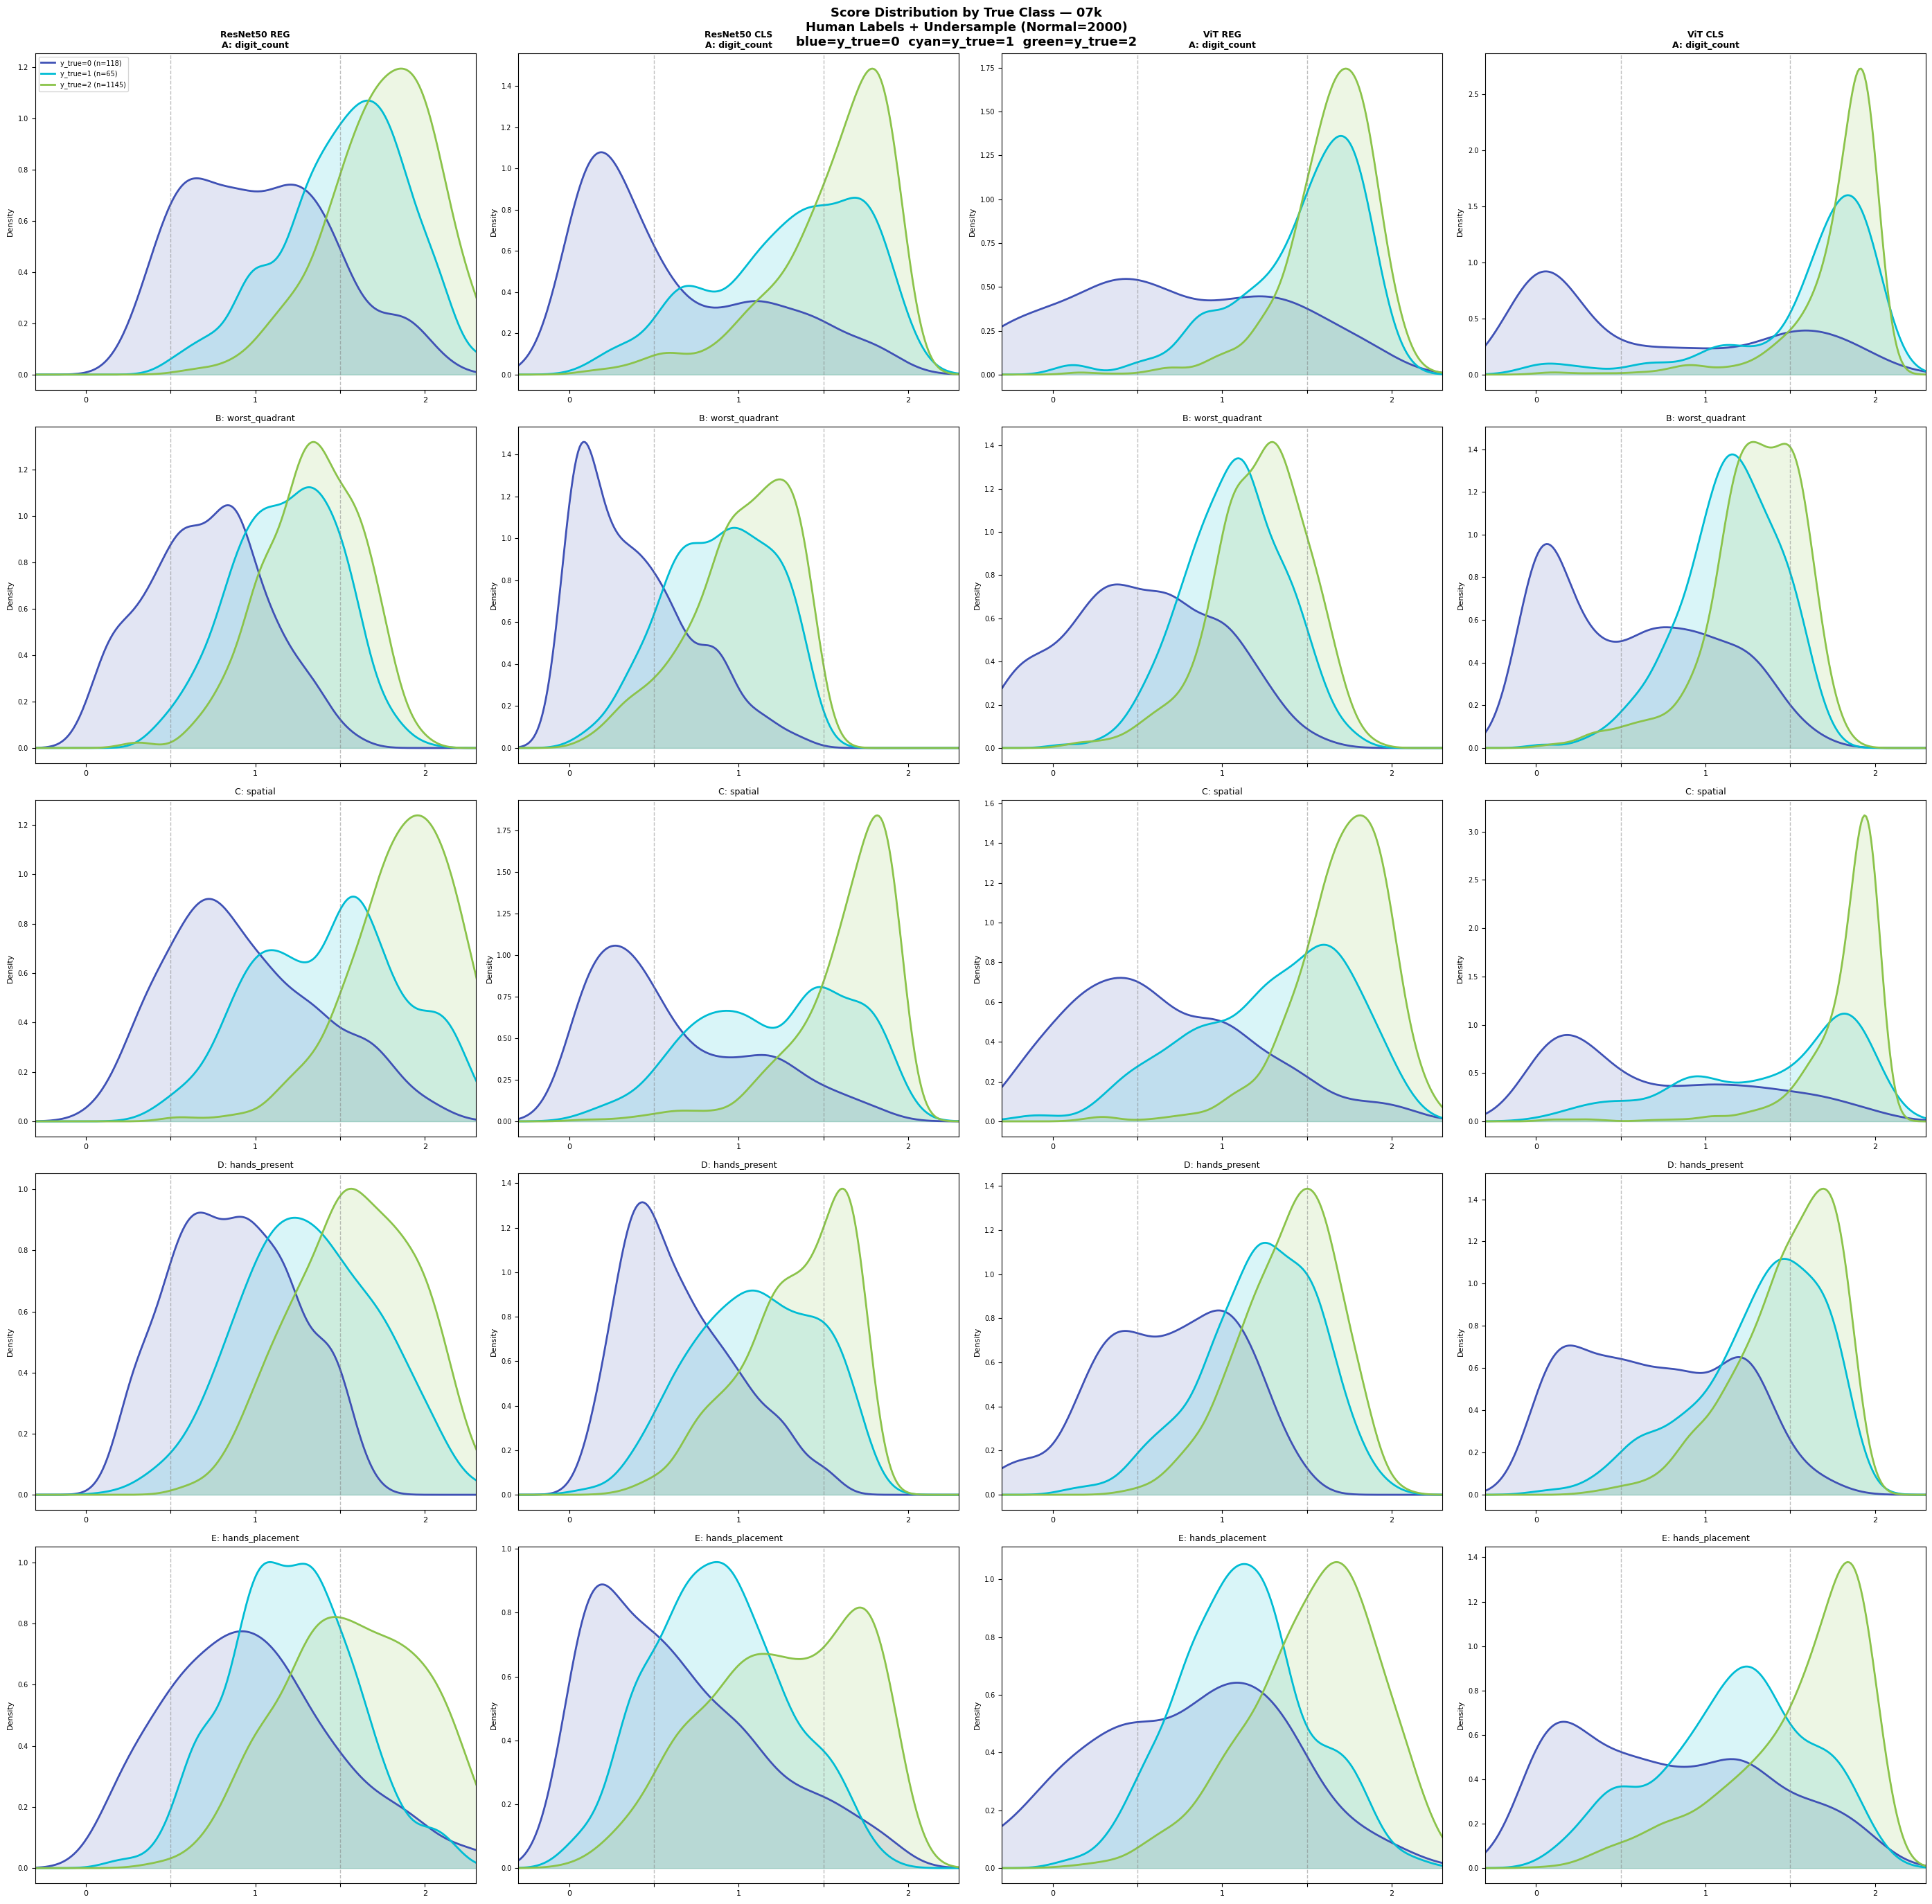

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np

domain_names_list = [
    (0, 'A: digit_count'),
    (1, 'B: worst_quadrant'),
    (2, 'C: spatial'),
    (3, 'D: hands_present'),
    (4, 'E: hands_placement'),
]

colors_true = {
    0: '#3F51B5',
    1: '#00BCD4',
    2: '#8BC34A',
}

model_keys  = list(all_models_raw.keys())
n_models    = len(model_keys)
short_names = {
    'resnet50_reg': 'ResNet50 REG',
    'resnet50_cls': 'ResNet50 CLS',
    'vit_reg'     : 'ViT REG',
    'vit_cls'     : 'ViT CLS',
}

fig, axes = plt.subplots(
    5, n_models,
    figsize=(n_models * 7, 7 * 4)
)

for d_idx, d_name in domain_names_list:
    for m_idx, m_key in enumerate(model_keys):
        ax      = axes[d_idx][m_idx]
        raw     = all_models_raw[m_key]['raw']
        labels  = all_models_raw[m_key]['labels']
        true_d  = labels[:, d_idx].astype(int)
        score_d = raw[:, d_idx]

        for true_val in [0, 1, 2]:
            mask   = (true_d == true_val)
            scores = score_d[mask]
            n      = mask.sum()

            if n < 5:
                continue

            try:
                kde    = gaussian_kde(scores, bw_method=0.3)
                x_vals = np.linspace(-0.5, 2.5, 300)
                y_vals = kde(x_vals)

                ax.plot(
                    x_vals, y_vals,
                    color=colors_true[true_val],
                    linewidth=2,
                    label=f'y_true={true_val} (n={n})'
                )
                ax.fill_between(
                    x_vals, y_vals,
                    color=colors_true[true_val],
                    alpha=0.15
                )
            except:
                ax.hist(
                    scores, bins=20,
                    color=colors_true[true_val],
                    alpha=0.4,
                    label=f'y_true={true_val} (n={n})',
                    density=True
                )

        for x in [0.5, 1.5]:
            ax.axvline(
                x=x, color='gray',
                linestyle='--', alpha=0.5,
                linewidth=1
            )

        ax.set_xlim(-0.3, 2.3)
        ax.set_xticks([0, 0.5, 1, 1.5, 2])
        ax.set_xticklabels(
            ['0', '', '1', '', '2'], fontsize=8
        )
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

        if d_idx == 0:
            ax.set_title(
                f'{short_names[m_key]}\n{d_name}',
                fontsize=9, fontweight='bold'
            )
        else:
            ax.set_title(d_name, fontsize=9)

        if d_idx == 0 and m_idx == 0:
            ax.legend(fontsize=7, loc='upper left')

plt.suptitle(
    'Score Distribution by True Class — 07k\n'
    'Human Labels + Undersample (Normal=2000)\n'
    'blue=y_true=0  cyan=y_true=1  green=y_true=2',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    f'{RESULT_FOLDER}/07k_score_distribution_kde.png',
    dpi=150, bbox_inches='tight'
)
plt.show()